In [32]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [33]:
from sklearn.preprocessing import StandardScaler

import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import torch.nn as nn
import importlib
from functools import partial
import pandas as pd
import copy
from cross_common import MEE,MSE,RMSE,MAE,R2

importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h1>NN - Manual</h1>
<h2>Exploring the cup dataset with NN Classifier.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [34]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# Scaler
scaler = StandardScaler()
# The train set used for model selection
# and final testing
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)

# Important!!!! The following dataset is prepared for investigation purpose and dry run of the NN pipeline,
# in order to check for correctness of function calls and graphics plot
# it is absolutely not meant to be used for model selection
dry_run_scaler = StandardScaler()
X_tr_dry_run, y_tr_dry_run, X_ts_dry_run, y_ts_dry_run = cc.prepare_dataset_for_hold_out(df_train, ratio=0.2, scaler=dry_run_scaler)

features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [35]:
# Set to True when model is selcted and assessed
dump_prediction = False

# scheduler_template: functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', factor=0.5, patience=10, threshold=0.01)
# optimizer_template: functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.001362704148730057, weight_decay=0.00029646406086810437, betas=(0.95, 0.999))
# loss_function: MEELoss(reduction='mean') - custom function
# early_stopping_strategy: EarlyStopping monitoring loss with patience=50, min_delta=0.01
# metrics: {'loss': (MEELoss(reduction='mean') - custom function, <built-in function min>), 'mse': (<function mse at 0x1218cbab0>, <built-in function min>), 'mae': (<function mae at 0x1218cbd70>, <built-in function min>), 'rmse': (<function rmse at 0x1218cbb60>, <built-in function min>)}
# hidden layers: [256, 128]

# epochs: 1000
# batch_size: 16
# scheduler_template: functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', factor=0.5, patience=10, threshold=0.01)
# optimizer_template: functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.007119785296884371, weight_decay=0.0003186696448140994, betas=(0.95, 0.999))
# loss_function: MEELoss(reduction='mean') - custom function
# early_stopping_strategy: EarlyStopping monitoring loss with patience=50, min_delta=0.01
# metrics: {'loss': (MEELoss(reduction='mean') - custom function, <built-in function min>), 'mse': (<function mse at 0x120403a00>, <built-in function min>), 'mae': (<function mae at 0x120403cc0>, <built-in function min>), 'rmse': (<function rmse at 0x120403ab0>, <built-in function min>)}
# hidden layers: [256, 128]

# Optuna parameters
optuna_epochs = 1000
optuna_batch_size = 32
optuna_learning_rate = 25e-3
optuna_weight_decay = 4e-4
optuna_hidden_layers = [256,128]
optuna_activation = "tanh"


# The seed to be used by data splitter
default_state = cr.RANDOM_STATE
default_seed = cr.SEED


# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 4


# ----- Defining model architecture --------
hidden_layers = optuna_hidden_layers
net = nnc.build_nn_net(input_dimension, output_dimension, hidden_layers, optuna_activation)

# The output and loss function, must be changed according to the type of task
#loss_function = nn.MSELoss()
loss_function = nnc.MEELoss()
output_adapter = nnc.regression_adapter()

# Model implementation
model_template = nnc.build_nn_model(net, output_adapter)
# ------------------------------------------


# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=optuna_learning_rate,
    weight_decay=optuna_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by learning rate will decrease
learning_rate_decay_factor = 0.5 #0.7    #0.6 #0.5
# The epoch to wait before applying the rate decay factor
learning_rate_decay_patience = 8
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 25 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = nnc.EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# ---- The additional metrics to compute ---
metrics_dict = {
    # The loss function is implicitly added during training
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    #R2: (cr.r2,max),
}
the_metrics = [cr.LOSS] + list(metrics_dict.keys())
# ------------------------------------------


<h3>NN Run</h3>
<p>The NN run is separated in two distinct scenarios independent from each other:
<ol>
<li>Hold-out: meant to be used for inspecting the correctness of the whole pipeline (i.e. no error, effectiveness of learning rate decay, plotting etc...).</li>
<li>KFold: meant to be used for model selection and asessment eventually leading to testing evaluation.</li>
</ol>
</p>
<hr/>

<h4>Hold-out</h4>
<p>Hold-out validation is used for preliminary inspection of learning dynamics, whereas final model selection based on K-Fold cross-validation.</p>

<h5>Training</h5>
<p>Training the model.</p>

In [36]:
print(the_metrics)

['loss', 'mse', 'mae', 'rmse', 'r2']


In [37]:
importlib.reload(nnc)
importlib.reload(cr)
# custom settings
# Either batch, online or the mini-batch size
ho_batch_size="batch"
ho_epochs=300
# Enabling Early stopping
ho_patience = 50 # patience <0 will disable early stopping
ho_min_delta = 1e-4 # ignored if early stopping disabled

# Clone an untrained model and its optimizer
model_dry_run = copy.deepcopy(model_template)

hold_out_result = nnc.train(
    model_dry_run, nnc.HoldOutStrategy(nnc.FeatureTargetSet(X_tr, y_tr), seed=default_seed, scaler=dry_run_scaler),
    optimizer_template,loss_function, batch_size=ho_batch_size, epochs=ho_epochs,
    early_stopping_strategy=nnc.EarlyStoppingStrategy(patience=ho_patience, min_delta=ho_min_delta),
    scheduler_template=scheduler_template,
    additional_metrics=metrics_dict
)


Early stopping at epoch 230 (best VL loss: 26.3264)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 300
Train           | samples: 400
Validation      | samples: 100
Batch type      | batch
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.025, 'weight_decay': 0.0004, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 8, 'threshold': 0.01}
Early Stopping  | metric: loss,  patience: 50 , minimum delta: 0.0001
----------------------------------------------------------------------------------------------------


In [38]:
epochs_tr_mee = hold_out_result.epochs_tr_loss
epochs_vl_mee = hold_out_result.epochs_vl_loss
epochs_grad = hold_out_result.epochs_grad_norm

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

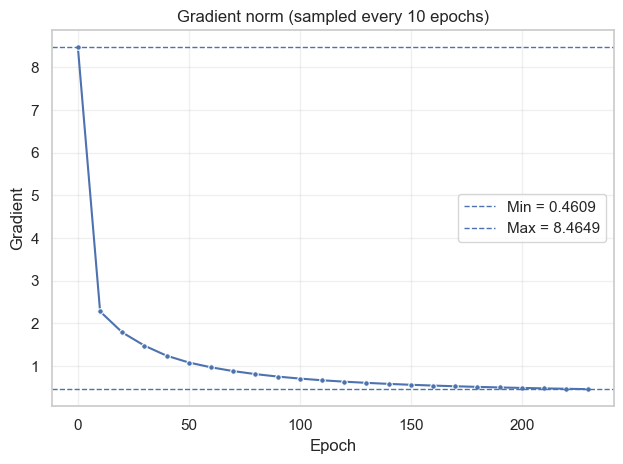

In [39]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

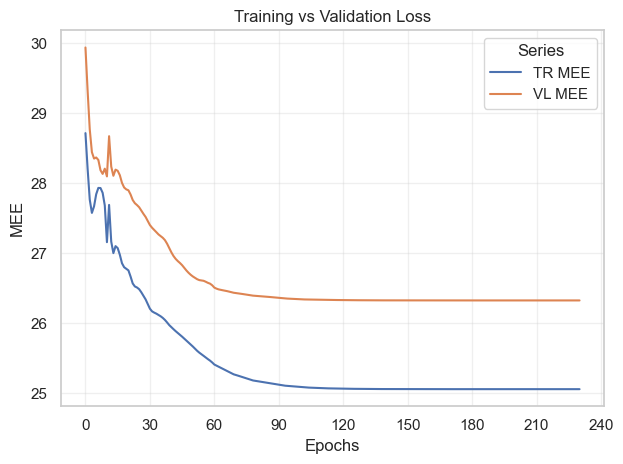

In [40]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_tr_mee, epochs_vl_mee)

In [41]:
best_vl_mee = min(hold_out_result.epochs_vl_loss)
best_epoch = hold_out_result.epochs_vl_loss.index(best_vl_mee)
print(f"min MEE: {best_vl_mee} - best epoch: {best_epoch}")


min MEE: 26.326322555541992 - best epoch: 219


<hr/>

<h4>KFold</h4>
<p>Model selection is performed using K-Fold cross-validation on the training data, while an initial hold-out split was used only for preliminary analysis and debugging.</p>

<h5>Run</h5>

In [46]:
importlib.reload(nnc)
importlib.reload(cc)

# The KFold strategy to be used through all models
outer_cv = cr.common_fold_strategy()


inner_train_params = {
    "epochs": optuna_epochs,
    "batch_size": optuna_batch_size,
    "scheduler_template": scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
    "additional_metrics": metrics_dict,
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, outer_cv, inner_train_params, scaler
)


  
Perform fold: 0, train size: 400, val size: 100
Early stopping at epoch 74 (best VL loss: 23.8645)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 400
Validation      | samples: 100
Batch type      | mini-batch (32)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.025, 'weight_decay': 0.0004, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 8, 'threshold': 0.01}
Early Stopping  | metric: loss,  patience: 25 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 400, val size: 100
Early stopping at epoch 136 (best VL loss: 22.6785)
Train summary
----------------------------------------------------------------------------------------------

In [43]:
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h5>Metrics</h5>
<p>Main metrics used for model assessment.
</p>

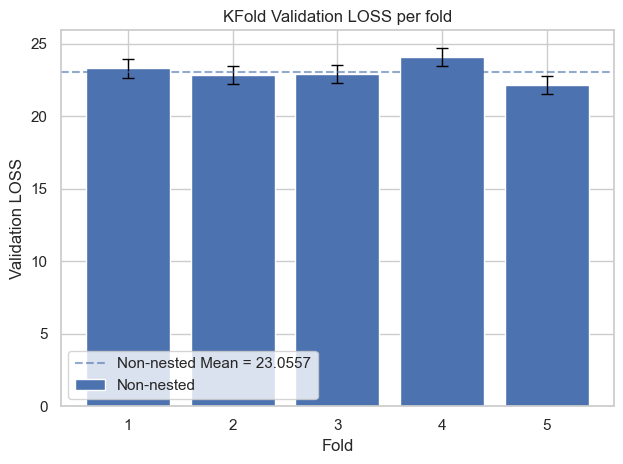

,TR,VL,Gap(TR-VL)
Fold,,,
1,20.232224,23.293843,3.061619
2,20.834620,22.819691,1.985071
3,21.060323,22.938764,1.878441
4,20.741607,24.063003,3.321396
5,21.414870,22.162954,0.748084
MEAN,20.856729,23.055651,2.198922
STD,0.389030,0.622534,0.922775


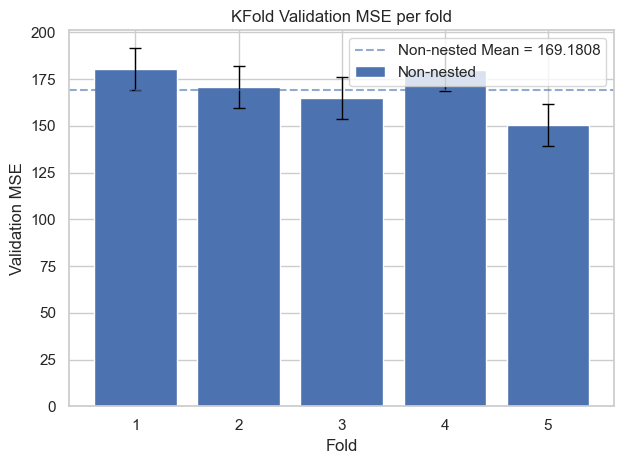

,TR,VL,Gap(TR-VL)
Fold,,,
1,136.364428,180.391158,44.026730
2,145.050956,170.699873,25.648916
3,148.284076,164.803880,16.519804
4,145.106210,179.607630,34.501420
5,151.427335,150.401691,-1.025644
MEAN,145.246601,169.180846,23.934245
STD,5.027498,11.031871,15.467923


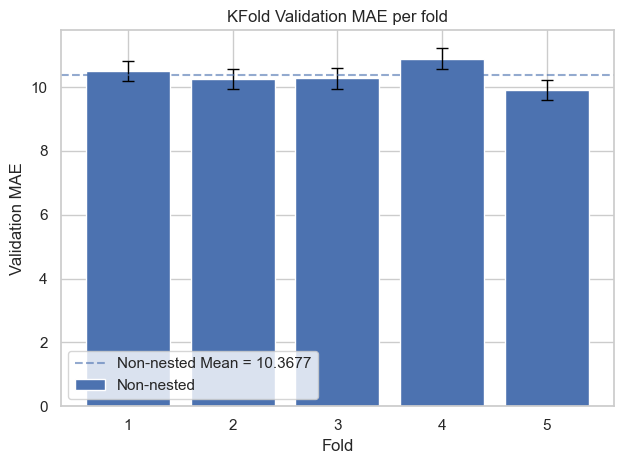

,TR,VL,Gap(TR-VL)
Fold,,,
1,9.000166,10.503340,1.503174
2,9.350236,10.252974,0.902738
3,9.417449,10.274221,0.856772
4,9.311421,10.894592,1.583171
5,9.653336,9.913373,0.260037
MEAN,9.346522,10.367700,1.021178
STD,0.209940,0.323829,0.483436


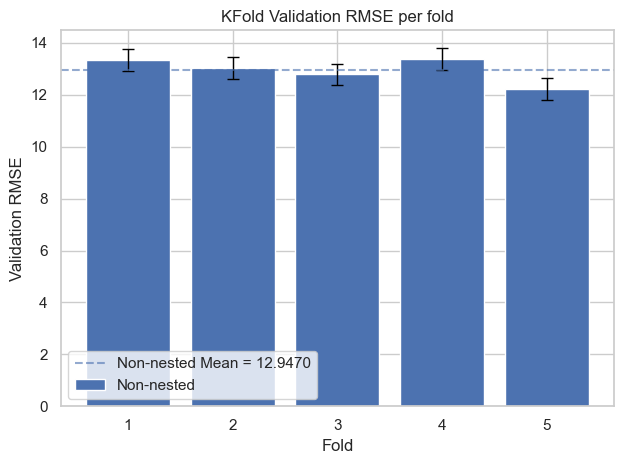

,TR,VL,Gap(TR-VL)
Fold,,,
1,11.595476,13.330049,1.734573
2,11.979063,13.020127,1.041064
3,12.098469,12.780863,0.682394
4,12.018962,13.371946,1.352984
5,12.205493,12.231827,0.026334
MEAN,11.979492,12.946962,0.967470
STD,0.207007,0.417547,0.584720


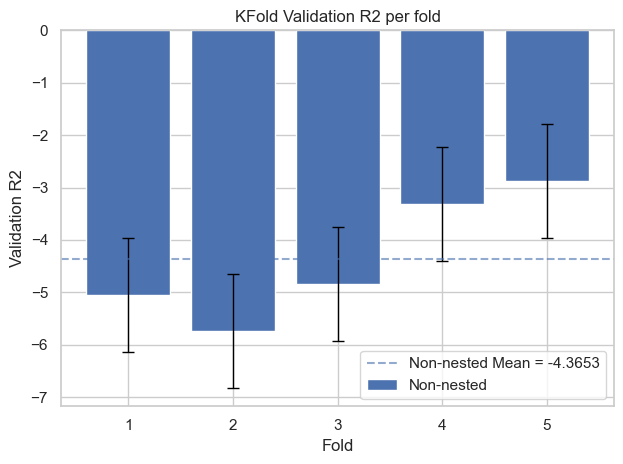

,TR,VL,Gap(TR-VL)
Fold,,,
1,-3.406806,-5.053418,-1.646612
2,-2.404653,-5.746431,-3.341778
3,-4.331147,-4.835311,-0.504165
4,-1.442629,-3.310688,-1.868059
5,-2.824548,-2.880572,-0.056025
MEAN,-2.881957,-4.365284,-1.483328
STD,0.967305,1.087986,1.151040


In [44]:
for metric in the_metrics:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_summary(fold_histories, use=metric))

<h5>Bootstrap Variance</h5>

In [45]:

epochs_metrics_bootstrap_dict = {
    MEE: (cr.mee, min)
}

importlib.reload(cr)
importlib.reload(nnc)
bootstrap_samples_nr = 50
bootstrap_rstate = cr.RANDOM_STATE
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples_nr, random_state=bootstrap_rstate)
runner = nnc.TorchRegressorRunner(model_template)
bootstrap_params = {}
bootstrap_params['train_params'] = copy.deepcopy(inner_train_params)
bootstrap_params['train_params']["silence_output"] = True
bootstrap_params['scaler'] = scaler
bootstrap_params['split_strategy'] = nnc.HoldOutStrategy
bootstrap_scores = cr.bootstrap_out_of_bag_scores(runner, X_tr, y_tr, samples, epochs_metrics_bootstrap_dict, bootstrap_params)

KeyboardInterrupt: 

In [ ]:
cr.aggregate_scores(bootstrap_scores)

In [ ]:
cr.plot_bootstrap_distribution([metric[MEE] for metric in bootstrap_scores], title=f"Bootstrap Distribution {MEE.upper()}")

In [ ]:
save_report = False
if save_report:
    metrics={}
    for metric, value in zip(["mee", "mse", "mae"],[
        ([f.fold_vl_mee for f in fold_histories],[f.fold_tr_mee for f in fold_histories]),
        ([f.fold_vl_mse for f in fold_histories],[f.fold_tr_mse for f in fold_histories]),
        ([f.fold_vl_mae for f in fold_histories],[f.fold_tr_mae for f in fold_histories])
        ]):

        metrics[metric] = (cr.mean_std_from_kfold(value[0]), cr.mean_std_from_kfold(value[1]))
        nnc.save_run_report(model_baseline, net,inner_train_params,metrics)

<h5>Training</h5>
<p>Model is eventually trained with best parameters verified from KFold, in order to predict on official test set.</p>

In [ ]:
# Prepare and scale datasets
X_tr, y_tr = cc.prepare_dataset(df_train, scaler=scaler, fit_scaler=True)   # fit+transform
X_ts, y_ts = cc.prepare_dataset(df_test,  scaler=scaler, fit_scaler=False)

model_final = copy.deepcopy(model_template)
final_scaler = StandardScaler()
train_kf_result = nnc.train(
    model_final, nnc.HoldOutStrategy(nnc.FeatureTargetSet(X_tr, y_tr), val_ratio=0.1, scaler=final_scaler),
    **inner_train_params
)

In [ ]:
epochs_kf_vl_mee = train_kf_result.epochs_vl_mee
epochs_kf_tr_mee = train_kf_result.epochs_tr_mee
epochs_kf_tr_mse = train_kf_result.epochs_tr_mse
epochs_kf_vl_mse = train_kf_result.epochs_vl_mse
epochs_kf_vl_mae = train_kf_result.epochs_vl_mae
epochs_kf_tr_mae = train_kf_result.epochs_tr_mae
epochs_kf_grad = train_kf_result.epochs_grad_norm


<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

In [ ]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=10)

<h5>Epoch Loss</h5>

In [ ]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_kf_tr_mee, epochs_kf_vl_mee)

<h3>Prediction</h3>
<p>Final model prediction if needed.</p>

In [ ]:
importlib.reload(nnc)
all_pred = model_final.predict(X_ts)
print(all_pred)
